In [ ]:
#exp no:06                Face Recognition using SVM Classifier

#ROLL NO: 230701244
#Name : PRAVEEN R


In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

In [2]:
faces = fetch_lfw_people(min_faces_per_person=60, resize=0.4)
X = faces.data
y = faces.target
target_names = faces.target_names
n_classes = len(target_names)

In [3]:
pca = PCA(n_components=150, svd_solver='randomized', whiten=True)
svm = SVC(kernel='rbf', class_weight='balanced')
model = make_pipeline(pca, svm)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
model.fit(X_train, y_train)

Pipeline(steps=[('pca',
                 PCA(n_components=150, svd_solver='randomized', whiten=True)),
                ('svc', SVC(class_weight='balanced'))])

In [5]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       1.00      0.80      0.89        15
     Colin Powell       0.66      0.96      0.78        68
  Donald Rumsfeld       0.93      0.84      0.88        31
    George W Bush       0.93      0.86      0.89       126
Gerhard Schroeder       0.94      0.65      0.77        23
      Hugo Chavez       1.00      0.65      0.79        20
Junichiro Koizumi       1.00      0.92      0.96        12
       Tony Blair       0.88      0.88      0.88        42

         accuracy                           0.85       337
        macro avg       0.92      0.82      0.85       337
     weighted avg       0.88      0.85      0.85       337



In [6]:
def plot_gallery(images, titles, h, w, n_row=3, n_col=4):
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray)
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())
    plt.show()

In [7]:
def title(y_pred, y_test, target_names, i):
    pred_name = target_names[y_pred[i]].rsplit(' ', 1)[-1]
    true_name = target_names[y_test[i]].rsplit(' ', 1)[-1]
    return 'predicted: %s\ntrue:      %s' % (pred_name, true_name)

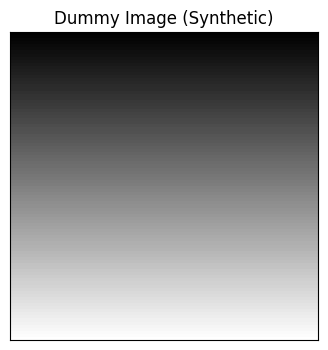

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Create a dummy image (e.g., a simple gradient or shape)
dummy_image = np.zeros((100, 100), dtype=np.uint8)
for i in range(100):
    dummy_image[i, :] = i * 2.55


plt.figure(figsize=(4, 4))
plt.imshow(dummy_image, cmap='gray')
plt.title('Dummy Image (Synthetic)')
plt.xticks([])
plt.yticks([])
plt.show()